# GIK2FB Artificial Intelligence HT25

## Regression Learning, Naive Bayes

Dalarna University (c) Joonas Pääkkönen

The aim of this lab is to familiarize yourself with Sklearn, so use Scikit-learn first and foremost as a source of information and Python methods, with the help of Pandas, NumPy, SciPy, Matplotlib and Seaborn, if needed.

In this lab, you do not need to split your data into training and testing. You can use all dataset for training your regression models.

Keep the questions as they are, so simply add your answers either in code cells or Markdown cells after the questions.

More about Markdown:

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html
https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet

## The following information is from Roger's "ML Supervised Classification  Learning", and the only practical differences are: 1) You may explain your answers in either Swedish or English, and 2) Only one JNB file for the whole lab, so only one video for the whole lab

### Grupparbete
- Arbeta i din Canvas-grupp enligt sidan Labbgrupper i Canvas.
- För att kunna lämna in måste du tillhöra en Canvas-grupp.

Vad som ska lämnas in i Canvas
I inlämningen ska följande ingå:

1. Källfiler med data, namnge med gruppnummer och uppgiftsnummer
2. En Jupyter Notebook
- Filformat: *.ipynb
- Välkommenterad kod på svenska eller engelska.
- Koden ska vara direkt körbar (använd korrekta/relativa sökvägar till datafiler).
3. Ett filmklipp
- Antingen videofil eller länk (t.ex. YouTube). Namge med gruppnummer och uppgiftsnummer.
- Skärminspelad presentation på svenska eller engelska av lösningen.
- OBS! Alla medverkande ska synas i en webbkameraruta med ansikte och fullständigt namn, annars underkänns inlämningen, se figur till höger.

### Muntlig redovisning via skärminspelning
- Varje student i gruppen redovisar. Fördela presentationstiden lika mellan er.
- Max 7 minuter per uppgift markerad med ScreenRec.

I filmklippet ska du:
- Demonstrera din lösning genom att köra koden live, visa med muspekare, eventuellt skriva kod och prata till inspelningen. Det är inte (kod-)syntax som är i fokus, det är hur du löst uppgiften. Metoder/funktioner för datahantering, träning, validering mm som hör till maskininlärning förklaras dock.
- Avsluta med en kort reflektion över uppgiften (vad du tyckte, vad som var intressant, vad du lärt dig och vad du vill lära dig mer om).
- Inget bakgrundsljud, t.ex. musik, får förekomma i inspelningen.

Använd valfri skärminspelare, till exempel OBS Studio (https://obsproject.com/), och lämna in länk till videon eller videofilen i Canvas på uppgiftens inlämningssida.

### Deadline
- Deadline framgår av uppgiftens inlämningssida i Canvas.

### OBS. Bara en Jupyter Notebook för hela labben

### Task 1: Getting used to scikit-learn.org

Task 1.1: Choose any regression metric from the sklearn.metrics module and explain in your own words what the metric measures and how. Also explain when you would, or would not, recommend using the regression metric that you chose.

***
##### Svar 1.1
from sklearn.metrics import max_error  
Denna funktion från sklearn tar emot predikterade och sanna värden och ger en variabel.  
Om variabeln ligger nära 0 kan man tyda detta som att modellen inte har mycket varians och kommer att ha hög accuracy.  
Det kan även användas för att hitta outliers inom datasettet.
***

Task 1.2: Explain the PolynomialFeatures method of the sklearn.preprocessing Python module. What is the PolynomialFeatures method? What can be done with it?

***
##### Svar 1.2
sklearn.preprocessing.PolynomialFeatures  
Skapar upp ett matrix utav polynom features. Om man skickar in [a, b], så skapas upp ett "degree-2 polynomial features matrix" [1, a, b, a^2, ab, b^2].  
t.ex:   
[0, 1] --> [ 1.,  0.,  1.,  0.,  0.,  1.]  
[2, 3] --> [ 1.,  2.,  3.,  4.,  6.,  9.]  
[4, 5] --> [ 1.,  4.,  5., 16., 20., 25.]  
***

Task 1.3: Keep the PolynomialFeatures method in mind, and consider a four-dimensional input sample of the form $(X_1,X_2,X_3,X_4)$. To what will these features be transformed if the *interaction_only* flag is set to True?

***
##### Svar 1.3
interaction_only  
Om man avnänder denna flagga så kommer resultaten där man höjer med 2 inte att inkulderas. t.ex a^2, b^2.  
dvs:  
[0, 1] --> [ 1.,  0.,  1., 0.]  
[2, 3] --> [ 1.,  2.,  3., 6.]  
[4, 5] --> [ 1.,  4.,  5., 20.]  
***

Task 1.4: Read the "Naive Bayes" page in the scikit-learn User Guide under Supervised learning, and answer the following question: What famous application of naive Bayes, other than the spam filtering application, does the page mention?

***
##### Svar 1.4
Dokument klassificering.  
Styrkan med naive bayes är att metoden är simplare och producerar snabba resultat.
***

Task 1.5: The same page explains what "naive" means in naive Bayes. Explain this in your own words.

***
##### Svar 1.5
"Naive" bayes.  
Naive kommer från att metoden inte är robust utan bygger på ett antagande där man antar att alla faktorer är betingat oberoende.  
Detta betyder att man räknar på faktorerna utan att ta till hänsyn hur dessa faktorer påverkar varann vilket leder till metodens simplicitet.
***

### Task 2: Linear regression

Task 2.1: Download the 'Scn2_GWP_NPV_pareto.csv' dataset from Canvas (the file is attached to the lab description on Canvas), and save the data into a variable called "paretodata" with the read.csv() method of the Pandas module. You need to import Pandas first.

In [1]:
import pandas as pd
paretodata = pd.read_csv("Scn2_GWP_NPV_pareto.csv")

Task 2.2: Print the paretodata dataset by simply writing the variable name.

In [2]:
paretodata

,Unnamed: 0,PV Roof,PV Facade,GWP,NPV,Normalized GWP,Normalized NPV,GWP_1,GWP_2,GWP 1 per kWh(gCO2e/kWh),GWP 2 per kWh(gCO2e/kWh),Feasibility
0,0,114.000000,0.000000,297646.723768,92701.742394,1.000000,1.000000,301321.308824,297646.723768,24.315091,24.018571,False
1,1,0.509934,129.000000,279679.122005,-92723.761582,0.000000,0.000000,280256.648042,279679.122005,22.615280,22.568677,True
2,2,33.391952,129.000000,279717.067049,-68578.670472,0.002112,0.130215,282061.033968,279717.067049,22.760885,22.571739,True
3,3,114.000000,88.544501,285411.392284,11115.245124,0.319034,0.560004,294074.239754,285411.392284,23.730290,23.031242,True
4,4,114.000000,114.765623,281865.320973,-15891.179006,0.121675,0.414358,292721.576697,281865.320973,23.621137,22.745092,True
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,12.319013,129.000000,279683.709946,-83585.366843,0.000255,0.049283,280769.223736,279683.709946,22.656643,22.569047,True
96,96,114.000000,26.029187,294020.680138,69848.376086,0.798190,0.876752,298882.241943,294020.680138,24.118271,23.725968,False
97,97,113.827461,34.291451,292869.554097,62355.297867,0.734123,0.836342,298126.113738,292869.554097,24.057255,23.633078,False
98,98,114.000000,11.570337,296033.257783,82622.268044,0.910201,0.945641,300215.416072,296033.257783,24.225851,23.888372,False


Task 2.3: How many observations does the dataset include?

In [4]:
len (paretodata)

100

Task 2.4: Use the Pandas describe() method to describe paretodata.

In [6]:
paretodata.describe()

,Unnamed: 0,PV Roof,PV Facade,GWP,NPV,Normalized GWP,Normalized NPV,GWP_1,GWP_2,GWP 1 per kWh(gCO2e/kWh),GWP 2 per kWh(gCO2e/kWh)
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,98.904464,81.702970,286372.377742,9143.321445,0.372518,0.549369,293125.173251,286372.377742,23.653705,23.108789
std,29.011492,31.850905,42.706215,5867.529024,51324.380580,0.326562,0.276792,5805.135490,5867.529024,0.468445,0.473480
min,0.000000,0.509934,0.000000,279679.122005,-92723.761582,0.000000,0.000000,280256.648042,279679.122005,22.615280,22.568677
25%,24.750000,112.775911,42.664373,280716.297886,-26759.838766,0.057725,0.355744,292479.455939,280716.297886,23.601599,22.652372
50%,49.500000,113.989644,91.601450,284992.967125,8026.035377,0.295746,0.543344,293884.939831,284992.967125,23.715014,22.997477
75%,74.250000,114.000000,124.939552,291716.093972,54834.402451,0.669926,0.795781,297432.923049,291716.093972,24.001318,23.539999
max,99.000000,114.000000,129.000000,297646.723768,92701.742394,1.000000,1.000000,301321.308824,297646.723768,24.315091,24.018571


Task 2.5: What is the numerical value of the NPV feature under which 25% of the observations fall?

In [7]:
paretodata["NPV"].quantile(0.25)

-26759.83876585525

Task 2.6: Explain in your own words what the describe() method shows you about the dataset.

#### describe() skriver ut statistiken för datasettet. Den visar medelvärdet, antal, min/max, standardavvikelsen, prosentiler

Task 2.7: In this lab we only use the NPV feature and the GWP feature. Save the NPV observations in a Pandas series called "x", and the GWP observations in a Pandas series called "y".

In [35]:
x = paretodata["NPV"]
y = paretodata["GWP"]

Task 2.8: Plot the corresponding $(x,y)$ scatterplot.

Text(0, 0.5, 'GWP')

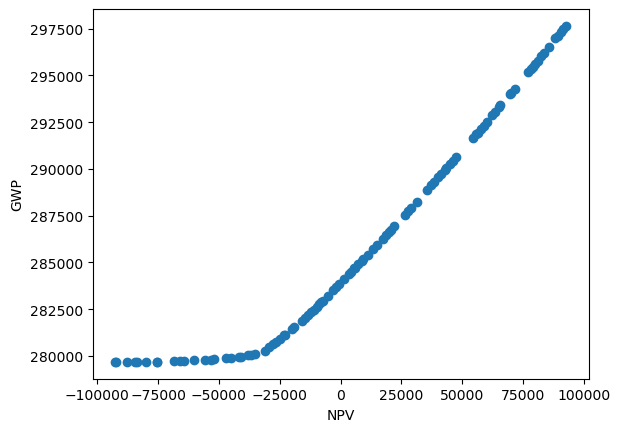

In [36]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel("NPV")
plt.ylabel("GWP")

Task 2.9: For the GWP against NPV dataset that you just (scatter)plotted, what is the range of interpolation?

**From minNPV to maxNPV**

Task 2.10: The scatterplot shows that GWP is rather constant when NPV is lower than a certain threshold value. When NPV is above this threshold value, GWP seems to increase linearly with NPV. Choose a good value threshold for this NPV-threshold. Motivate your choice based on the dataset. It would be a good idea to write a little bit of code here.

**Scatterplotten visar att GWP ligger väldigt konstant när NVP är under ca -35 000. När NVP passerar ungefär -35 000 så ökar GWP kraftigt och blir linjärt.**

**Så därför sätter jag NPV_threshold = -35 000.**


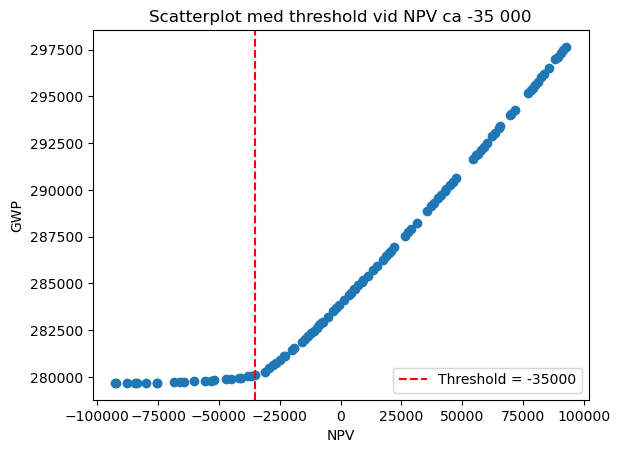

In [37]:
threshold = -35000


plt.scatter(x, y)
plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold = {threshold}")
plt.xlabel("NPV")
plt.ylabel("GWP")
plt.title("Scatterplot med threshold vid NPV ca -35 000")
plt.legend()
plt.show()

Task 2.11: Fit a linear regression model to this (NPV,GWP) dataset: Use LinearRegression from sklearn.linear_model, and plot the regression line and the scatterplot in the same figure.

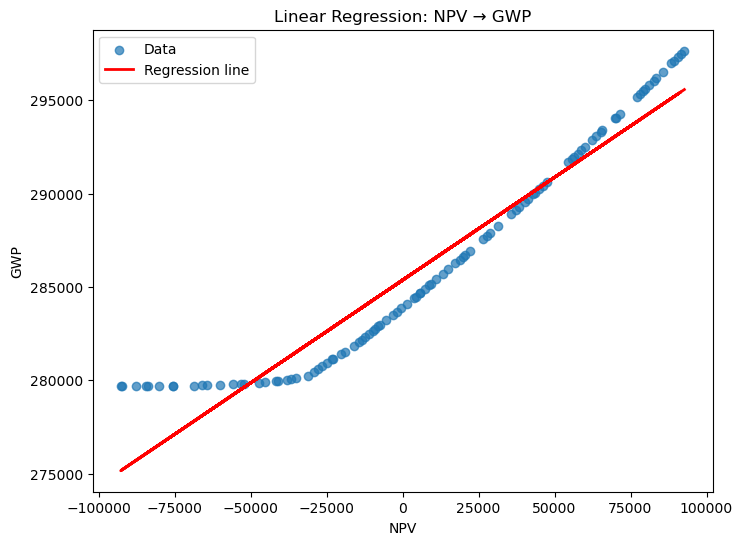

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Steg 1: Forma om x till 2D-array (krav för sklearn)
X = x.values.reshape(-1, 1)
Y = y.values

# Steg 2: Skapa och träna modellen
model = LinearRegression()
model.fit(X, Y)

# Steg 3: Prediktioner för alla x-värden
y_pred = model.predict(X)

# Steg 4: Plotta scatter + regressionslinje
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Data", alpha=0.7)
plt.plot(x, y_pred, color="red", linewidth=2, label="Regression line")

plt.xlabel("NPV")
plt.ylabel("GWP")
plt.title("Linear Regression: NPV → GWP")
plt.legend()
plt.show()


Task 2.12: Apply the "score" method (of sklearn.linear_model.LinearRegression) to the real values and the predicted values obtained by your model. What is the numerical value of this "score"? Explain in your own words what this "score" means.

In [39]:
model.score(X, y)

0.9265241636793241

**model.score(X, y) beräknar modellens R^2-värde.**

**R^2 visar hur korrekt den linjära modellen förklarar variationen i datan.**

**Om värdet är nära 1 så är modellen bra för datan, är värdet 0 eller under så förklarar modellen datan dåligt.**

Task 2.13: Looking at the scatterplot and the fitted linear regression line above (the plot produced by Task 2.11), one might argue that fitting a simple linear regression line would not be the best idea. Would you have a better idea? As a bonus, if you want, you can implement your idea here and build a better regression model.

**En bättre modell kan vara att använda polynomial regression.**

**Denna modell kan böja sig och följa den form som scatterplotten visar.**

**Polynomial regression kan därför vara bättre anpassad än en enkel rak linje.**

Task 2.14: Write a Python method that calculates the optimal values of the Ordinary Least Squares (OLS) parameter (weights) $w_1$ and $w_0$. You can use the formulas in the slides. Note: write two separate methods: one for $w_1$ and another one for $w_0$.

In [40]:
import numpy as np

def ols_w1(x, y):
    """
    Beräknar OLS-lutningen w1 för enkel linjär regression.
    x och y är 1D-arrayer eller pandas-serier.
    """
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)
    w1 = numerator / denominator
    return w1

def ols_w0(x, y):
    """
    Beräknar OLS-skärningen w0 för enkel linjär regression.
    Använder w1 från ols_w1-funktionen.
    """
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    w1 = ols_w1(x, y)
    w0 = y_mean - w1 * x_mean
    return w0

w1 = ols_w1(x, y)
w0 = ols_w0(x, y)

print("w1 (lutning):", w1)
print("w0 (skärning):", w0)


w1 (lutning): 0.1100423623023932
w0 (skärning): 285366.2250509255


**`w1` (lutningen) beräknas med:**
  
**w₁ = Σ (xᵢ − x̄)(yᵢ − ȳ) / Σ (xᵢ − x̄)²**

**`w0` (skärningen) beräknas med:**

**w₀ = ȳ − w₁ · x̄**


Task 2.15: What are the values of the slope and the intercept given by the regression model that you built in Task 2.11? Note: there are built-in commands in Sklearn to extract these values for a regression model.

 **`coef_` → w₁ (lutningen)**

**`intercept_` → w₀ (skärning i y-axeln)**

Task 2.16: What are the slope and intercept values for the (NPV, GWP) dataset given by the methods that you wrote yourself in Task 2.14?

In [41]:
w1_own = ols_w1(x.values, y.values)
w0_own = ols_w0(x.values, y.values)

print("w1 (egen OLS, lutning):", w1_own)
print("w0 (egen OLS, intercept):", w0_own)


w1 (egen OLS, lutning): 0.1100423623023932
w0 (egen OLS, intercept): 285366.2250509255



**Här använder jag mina egna funktioner `ols_w1` och `ols_w0` från Task 2.14 för att beräkna w₁ och w₀ direkt från datan.**

Task 2.17: Do the values you got in Task 2.15 coincide with those of Task 2.16?

**Resultaten från `LinearRegression` (sklearn) och mina egna OLS-funktioner är i praktiken samma:**

**- w₁ från sklearn och w₁ från egen metod är nästan identiska.**

**- w₀ från sklearn och w₀ från egen metod är också nästan identiska.**


### Task 3: Probability theory and Bayes' theorem

Task 3.1: Consider the figure below. Assume that each small grid square is of unit area (area 1). What is the total area of the whole grid?

***
##### Task 3.1
Rutnätet är 20 rutor brett och 20 rutor högt, så den totala arean blir då 20 × 20 = 400
***

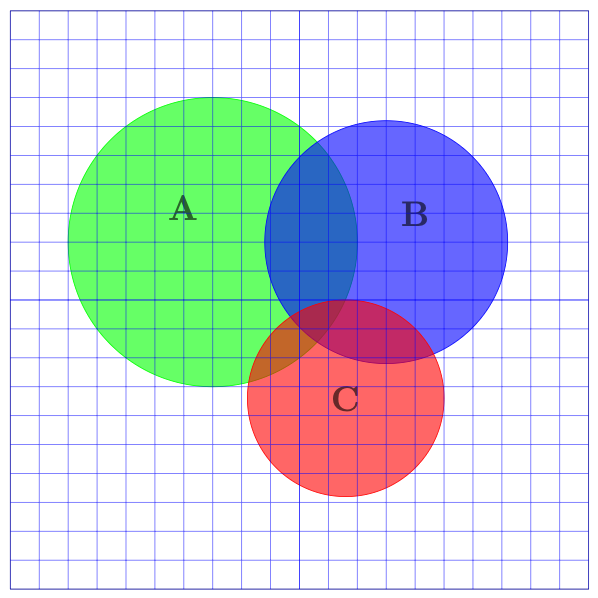

Task 3.2: Consider events A, B and C, the probabilities of which are represented by the areas of the green circle (A), the blue circle (B) and the red circle (C). The whole blue grid represents all possible events, that is, probability 1. The probability of A, $P(A)$, is hence the area of the green circle divided by the area of the whole grid. Based on the figure, estimate the numerical value of $P(A)$. Use any numerical methods and/or calculations that you want.

***
##### Task 3.2
Cirkel A sträcker sig över 10 små rutor (från vänsterkant till högerkant av cirkeln). Radien är därför
r_A = 10 / 2 = 5 rutor.

Arean av en cirkel beräknas med formeln A = π * r² / Total arean.
För cirkel A blir areaenheterna:

Area_A = π * 5² = 25π areaenheter.

Numeriskt värde:

P(A) ≈ P(A) beräknas som 25π dividerat med 400.


P(A) ≈ 0.196.

Slutsats:
P(A) ≈ 0.196.
***


Task 3.3: Do the same for $P(B)$.

***
##### Task 3.3
Cirkel B sträcker sig ungerfärligt 8  rutor (från vänsterkant till högerkant av cirkeln). Radien är därför
r_B = 8 / 2 = 4 rutor.

Arean av en cirkel beräknas med formeln B = π * r² / Total arean.
För cirkel B blir areaenheterna:

Area_B = π * 4² = 16π areaenheter.

Numeriskt värde:

P(B) ≈ P(B) beräknas som 16π dividerat med 400.


P(B) ≈ 0,1257

Slutsats:
P(B) ≈ 0,1257
***

Task 3.4: Do the same for $P(C)$.

***
##### Task 3.4
Cirkel C sträcker sig ungerfärligt 6  rutor (från vänsterkant till högerkant av cirkeln). Radien är därför
r_C = 6 / 2 = 3 rutor.

Arean av en cirkel beräknas med formeln C = π * r² / Total arean.
För cirkel C blir areaenheterna:

Area_C = π * 3² = 9π areaenheter.

Numeriskt värde:

P(C) ≈ P(C) beräknas som 9 π dividerat med 400.


P(C) ≈ 0.0707

Slutsats:
P(C) ≈ 0.0707
***

Task 3.5: Find $P(A|C)$. Use any numerical methods and/or calculations that you want.

***
#####   Task 3.5
Sannolikheten för snittet P(A ∩ C)
Det överlappande området mättes genom att räkna rutor:
Area(A ∩ C) ≈ 16 rutor
Total area = 400 rutor

P(A ∩ C) = 16 / 400 = 0,04


Beräkning av P(A | C)

P(A | C) = P(A ∩ C) / P(C) = 0,04 / 0,0707 ≈ 0,566

P(A | C) = ≈ 0,566
***

Task 3.6: Find $P(B|C)$. Use any numerical methods and/or calculations that you want.

***
#####   Task 3.6
Sannolikheten för snittet P(B ∩ C)
Vi uppskattar arean genom att räkna rutor i det färgade området:
Uppskattad area ≈ 11 rutor 

P(B ∩ C) ≈ 11 / 400 = 0.0275

Slutlig beräkning av P(B | C)

P(B | C) = P(B ∩ C) / P(C) ≈  0.0275 / 0.0707 ≈ 0.38897
***

Task 3.7: Use the Bayes' theorem to find $P(C|B)$. You may write fractions in these Markdown cells like this: $\frac{x+y}{y+x}$ (double-click this to see the source code).

***
#####   Task 3.6
Sannolikheten för snittet P(B ∩ C)
Vi använder samma uppskattning som i föregående steg:
P(B ∩ C) ≈ 11 / 400 = 0.0275

Sannolikheten för händelse B, P(B)
 = 50,27 / 400 ≈ 0,1257

C. Slutlig beräkning av P(C | B)

P(C | B) = P(B ∩ C) / P(B) ≈ 
$\frac{11 / 400}{50.27 / 400} = \frac{11}{50.27} \approx 0.22$
***

Note: you do not need to find extremely precise with your answers, but your calculations must be accurate enough and well-motivated. If you carefully solve each of the tasks above, the chances of you passing this lab on the first try will be high.